## Laboratorio 5 - One vs. All
**Nombre:** Plaza López Cesar Manuel

**Carrera:** Ingeniería de Sistemas

## Preprocesamiento de Datos

In [2]:
import os
import cv2
import numpy as np
import scipy.io

# 1. Rutas y configuración de clases
dataset_dir = 'Rice_Image_Dataset'
classes = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

X_list = []
y_list = []

print("Procesando las 75,000 imágenes...")

# 2. Recorrer las subcarpetas y convertir las fotos a matriz
for label_idx, class_name in enumerate(classes):
    class_folder = os.path.join(dataset_dir, class_name)
    if os.path.exists(class_folder):
        for img_name in os.listdir(class_folder):
            if img_name.endswith(('.jpg', '.png', '.jpeg')):
                img_path = os.path.join(class_folder, img_name)
                
                # Leer en escala de grises y redimensionar a 28x28 (784 píxeles)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img_resized = cv2.resize(img, (28, 28))
                    X_list.append(img_resized.flatten()) # Vector de 784 características
                    y_list.append(label_idx)

# 3. Formatear a matrices de NumPy
X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int64).reshape(-1, 1)

print(f"Dimensiones de X: {X.shape}") # Debería ser (75000, 784)
print(f"Dimensiones de y: {y.shape}") # Debería ser (75000, 1)

# 4. Guardar en formato .mat comprimido
output_filename = 'dataset_laboratorio.mat'
scipy.io.savemat(output_filename, {'X': X, 'y': y}, do_compression=True)

print(f"¡Éxito! Archivo '{output_filename}' creado y listo para enviar.")

Procesando las 75,000 imágenes...
Dimensiones de X: (75000, 784)
Dimensiones de y: (75000, 1)
¡Éxito! Archivo 'dataset_laboratorio.mat' creado y listo para enviar.


## 1.- Librerías

In [4]:
# utilizado para la manipulación de directorios y rutas
import os

# Cálculo científico y vectorial para python
import numpy as np

# Libreria para graficos
from matplotlib import pyplot

# Modulo de optimizacion en scipy
from scipy import optimize

# modulo para cargar archivos en formato MATLAB
from scipy.io import loadmat

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

# CARGA DE NUESTRO DATASET
data = loadmat('dataset_laboratorio.mat')
X = data['X']
y = data['y']

# Verificar dimensiones
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Dimensiones de X: (75000, 784)
Dimensiones de y: (75000, 1)


In [5]:
# Ingresar imágenes de granos de arroz de 28x28
input_layer_size = 784

# 5 etiquetas (clases de 0 a 4: Arborio, Basmati, Ipsala, Jasmine, Karacadag)
num_labels = 5

# datos de entrenamiento almacenados en los arreglos X, y
data = loadmat('dataset_laboratorio.mat')

X, y = data['X'], data['y'].ravel()

# Nota: No necesitamos la línea "y[y == 10] = 0" porque nuestras etiquetas
# ya están correctamente indexadas en Python desde 0 hasta 4.

m = y.size

# Verificación de parámetros básicos
print(f"Número de características (input_layer_size): {input_layer_size}")
print(f"Número de clases (num_labels): {num_labels}")
print(f"Número total de muestras (m): {m}")

Número de características (input_layer_size): 784
Número de clases (num_labels): 5
Número total de muestras (m): 75000


### 1.2 Visualización de los datos

Se comenzará visualizando un subconjunto del conjunto de entrenamiento. Se selecciona al azar, 100 filas de `X` y pasa esas filas a la función` displayData`. 

In [6]:
### 1.2 Visualización de los datos

def displayData(X, example_width=None, figsize=(10, 10)):
    """
    Muestra datos 2D almacenados en X en una cuadrícula apropiada.
    """
    # Calcula filas, columnas
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]  # Promocionar a una matriz bidimensional
    else:
        raise IndexError('La entrada X debe ser 1 o 2 dimensional.')

    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = int(n / example_width)

    # Calcula el número de elementos a mostrar
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        # Usamos order='C' para que no rote la matriz proveniente de NumPy
        ax.imshow(X[i].reshape(example_width, example_height, order='C'),
                  cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')

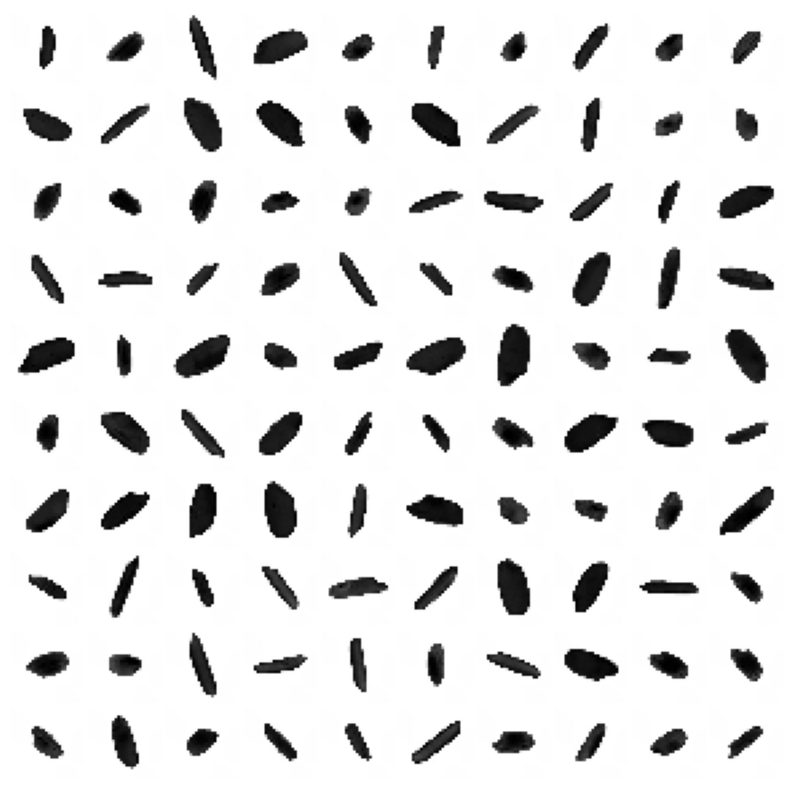

In [7]:
# Selecciona aleatoriamente 100 puntos de datos para mostrar
rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]

displayData(sel)

### 1.3 Vectorización de regresión logística

Se utilizará múltiples modelos de regresión logística uno contra todos para construir un clasificador de clases múltiples. Dado que hay 10 clases, deberá entrenar 10 clasificadores de regresión logística separados. Para que esta capacitación sea eficiente, es importante asegurarse de que el código esté bien vectorizado.

En esta sección, se implementará una versión vectorizada de regresión logística que no emplea ningún bucle "for".

Para probar la regresión logística vectorizada, se usara datos personalizados como se definen a continuación.

In [8]:
# valores de prueba para los parámetros theta
theta_t = np.array([-2, -1, 1, 2], dtype=float)

# valores de prueba para las entradas
X_t = np.concatenate([np.ones((5, 1)), np.arange(1, 16).reshape(5, 3, order='F')/10.0], axis=1)

# valores de testeo para las etiquetas
y_t = np.array([1, 0, 1, 0, 1])

# valores de testeo para el parametro de regularizacion
lambda_t = 3

### 1.3.1 Función de costo y gradiente vectorizados

In [14]:
def sigmoid(z):
    """
    Calcula la sigmoide de z de forma numéricamente estable.
    """
    # Evita el desbordamiento (overflow) recortando los valores de z entre -500 y 500
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

In [10]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo de usar theta como parámetro para la regresión logística regularizada y
    el gradiente del costo con respecto a los parámetros.
    """
    # Inicializa algunos valores útiles
    m = y.size

    # Convierte las etiquetas a valores enteros si son booleanos
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    # Hipótesis
    h = sigmoid(X.dot(theta))

    # Parámetro de regularización (sin regularizar theta[0])
    temp = theta.copy()
    temp[0] = 0

    # Pequeña tolerancia para evitar log(0)
    eps = 1e-15
    h = np.clip(h, eps, 1 - eps)

    # Cálculo del costo regularizado
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    # Cálculo del gradiente regularizado
    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp

    return J, grad

#### 1.3.3 Vectorización regularizada de la regresión logística


In [11]:
J, grad = lrCostFunction(theta_t, X_t, y_t, lambda_t)

print('Costo         : {:.6f}'.format(J))
print('Costo esperadot: 2.534819')
print('-----------------------')
print('Gradientes:')
print(' [{:.6f}, {:.6f}, {:.6f}, {:.6f}]'.format(*grad))
print('Gradientes esperados:')
print(' [0.146561, -0.548558, 0.724722, 1.398003]');

Costo         : 2.534819
Costo esperadot: 2.534819
-----------------------
Gradientes:
 [0.146561, -0.548558, 0.724722, 1.398003]
Gradientes esperados:
 [0.146561, -0.548558, 0.724722, 1.398003]


### 1.4 Clasificacion One-vs-all


In [15]:
# Escalar los píxeles de [0, 255] a [0, 1] para estabilidad matemática
if X.max() > 1.0:
    X = X / 255.0

print(f"Rango de valores en X: mín={X.min()}, máx={X.max()}")

Rango de valores en X: mín=0.0, máx=1.0


In [16]:
### 1.4 Clasificacion One-vs-all

def oneVsAll(X, y, num_labels, lambda_):
    """
    Trains num_labels logistic regression classifiers and returns
    each of these classifiers in a matrix all_theta, where the i-th
    row of all_theta corresponds to the classifier for label i.
    """
    # algunas variables utiles
    m, n = X.shape

    all_theta = np.zeros((num_labels, n + 1))

    # Agrega unos a la matriz X (término de intercepción / bias)
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        # Se aumentan las iteraciones a 100 para asegurar convergencia con 784 características
        options = {'maxiter': 100} 
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                options=options)
        all_theta[c] = res.x

    return all_theta

In [17]:
# Definición del parámetro de regularización y entrenamiento
lambda_ = 0.001
all_theta = oneVsAll(X, y, num_labels, lambda_)

In [ ]:
# Imprimir dimensiones y primeros pesos
print(f"Dimensiones de all_theta: {all_theta.shape}")
print("Primeros 10 pesos de la primera clase (Arborio):")
print(all_theta[0][:10])

Dimensiones de all_theta: (5, 785)
Primeros 10 pesos de la primera clase (Arborio):
[-14.37601828   0.           0.           0.           0.
   0.           0.           0.           0.           0.        ]


#### 1.4.1 Prediccion One-vs-all


In [19]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones para cada ejemplo en la matriz X.
    """
    m = X.shape[0]
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Agregar la columna de unos (término de intercepción / bias)
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    
    # Calcular probabilidades y seleccionar la clase con la máxima probabilidad
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)

    return p

Una vez que haya terminado, se llama a la función `predictOneVsAll` usando el valor aprendido de $\theta$. 

(75000, 784)
Precision del conjuto de entrenamiento: 95.42%
(100, 784)
(100, 785)

--- COMPARACIÓN (Predicción vs Real) ---
Predicciones (p): [3 0 4 2 1 3 3 0 4 1 1 0 1 1 1 0 1 3 4 0 2 2 0 1 3 3 3 4 0 1 2 2 0 0 0 1 3
 4 3 2 4 1 4 3 4 4 0 2 1 4 2 3 4 1 1 4 4 4 2 0 1 1 3 0 2 0 3 2 1 1 2 4 2 1
 4 0 3 4 4 0 2 3 2 3 3 0 4 4 1 3 1 0 0 4 3 2 4 1 1 2]
Etiquetas Reales: [3 0 4 2 1 3 3 0 4 1 1 0 1 1 1 0 1 0 0 0 2 2 0 1 3 3 3 4 0 1 2 2 0 0 0 1 3
 4 3 2 4 1 4 3 4 4 0 2 1 4 2 3 4 1 1 4 4 4 2 0 1 1 3 0 2 0 3 2 1 1 2 4 2 1
 4 0 3 4 4 0 2 3 2 3 3 0 4 4 1 3 1 0 0 4 3 3 4 1 1 2]


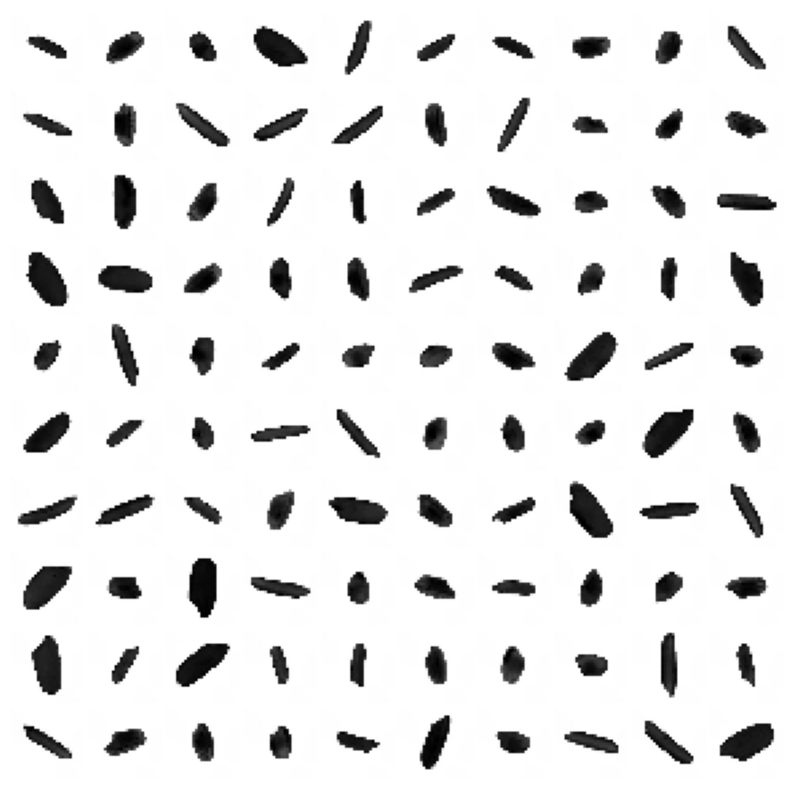

In [20]:
print(X.shape)
pred = predictOneVsAll(all_theta, X)
print('Precision del conjuto de entrenamiento: {:.2f}%'.format(np.mean(pred == y) * 100))

# Selecciona aleatoriamente 100 puntos de datos para mostrar
rand_indices = np.random.choice(m, 100, replace=False)
XPrueba = X[rand_indices, :].copy()
XPruebaV = XPrueba.copy()

print(XPrueba.shape)

# Agregar término de intercepción (bias) para la prueba
XPrueba = np.concatenate([np.ones((100, 1)), XPrueba], axis=1)
print(XPrueba.shape)

# Obtener las clases predichas para la muestra
p = np.argmax(sigmoid(XPrueba.dot(all_theta.T)), axis=1)

print("\n--- COMPARACIÓN (Predicción vs Real) ---")
print("Predicciones (p):", p)
print("Etiquetas Reales:", y[rand_indices])

# Desplegar la cuadrícula de 100 imágenes probadas
displayData(XPruebaV)